![image.png](https://i.imgur.com/a3uAqnb.png)

# Transformer from Scratch for Text Summarization 

In this  assignment, you will implement a **complete Transformer architecture from scratch** for text summarization using the BBC News dataset. This project will deepen your understanding of attention mechanisms, positional encoding, and sequence-to-sequence modeling.

## 🎯 Project Overview
- **Task**: Automatic text summarization of BBC news articles
- **Architecture**: Full Transformer (Encoder-Decoder) implementation from scratch
- **Dataset**: BBC News Summary Dataset
- **Goal**: Build and train a production-ready summarization model

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand and implement multi-head self-attention mechanisms
- Build positional encoding for sequence modeling
- Implement complete Encoder-Decoder Transformer architecture
- Learn advanced training techniques (label smoothing, gradient clipping, learning rate scheduling)
- Evaluate summarization quality using ROUGE metrics
- Master sequence generation and beam search techniques

## 1️⃣ Dataset Download and Initial Exploration

**Task**: Download the BBC News dataset and explore its structure for summarization.

**Requirements**:
- Download BBC News Summary dataset from Kaggle
- Explore the directory structure (articles vs summaries)
- Analyze article and summary length distributions
- Understand the data format and categories

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import re


# TODO: Download the BBC News Summary dataset
path = kagglehub.dataset_download("pariza/bbc-news-summary")


# TODO: Implement function to explore dataset structure
# TODO: Navigate to articles and summaries directories
# TODO: Count files in each category
# TODO: Return directory paths and category lists
# TODO: Explore dataset structure and display basic statistics
# TODO: Load and display sample article and summary to understand data format

Total articles loaded: 2225
Sample article length: 250 words
Sample summary length: 108 words


## 2️⃣ Import Required Libraries

**Task**: Import all necessary libraries for Transformer implementation and training.

**Requirements**:
- Import PyTorch and neural network modules
- Import text processing utilities
- Import evaluation metrics (ROUGE)
- Set up visualization libraries

In [2]:
# TODO: Install required libraries if needed
# !pip install rouge-score

In [ ]:
# TODO: Import core PyTorch libraries for neural network implementation
# TODO: Import data processing and utility libraries

## 3️⃣ Data Loading and Text Preprocessing

**Task**: Create a comprehensive data loading pipeline with text cleaning.

**Requirements**:
- Implement BBCNewsDataset class for loading articles and summaries
- Create robust text cleaning function
- Load all categories (politics, entertainment, sport, tech, business)
- Handle encoding errors and empty files
- Display dataset statistics

In [ ]:
class BBCNewsDataset:
    """
    TODO: Implement comprehensive dataset loader for BBC News data
    This class should handle:
    - Loading articles and corresponding summaries
    - Text cleaning and preprocessing
    - Error handling for corrupted files
    """
    def __init__(self, base_path):
        # TODO: Initialize paths and load data

    def clean_text(self, text):
        """
        TODO: Implement text cleaning function
        - Remove special characters and punctuation
        - Convert to lowercase
        - Normalize whitespace
        - Keep only alphanumeric characters and spaces
        """

    def load_all_data(self):
        """
        TODO: Load all articles and summaries from all categories
        - Iterate through all category directories
        - Match articles with their corresponding summaries
        - Apply text cleaning
        - Handle file reading errors gracefully
        """

# TODO: Load the complete dataset and convert to DataFrame
# TODO: Convert to pandas DataFrame for easier manipulation

Loaded 2225 article-summary pairs
Dataset shape: (2225, 4)
Categories: category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 4️⃣ Vocabulary Construction

**Task**: Build a comprehensive vocabulary for the Transformer model.

**Requirements**:
- Create Vocabulary class with special tokens (< pad >, < sos >, < eos >, < unk >)
- Implement frequency-based vocabulary filtering
- Handle encoding and decoding of text sequences
- Build vocabulary from both articles and summaries

In [ ]:
class Vocabulary:
    """
    TODO: Implement vocabulary class for text tokenization
    This class should handle:
    - Building vocabulary from text corpus
    - Converting text to token indices
    - Converting indices back to text
    - Handling out-of-vocabulary words
    """
    def __init__(self, min_freq=2):
        # TODO: Initialize special tokens and mappings

    def build_vocabulary(self, texts):
        """
        TODO: Build vocabulary from list of texts
        - Count word frequencies across all texts
        - Add words meeting minimum frequency threshold
        - Create bidirectional word-index mappings
        """

    def encode(self, text, max_length=None):
        """
        TODO: Convert text to sequence of token indices
        - Split text into words
        - Convert words to indices using vocabulary
        - Handle unknown words with <unk> token
        - Add <eos> token and apply length limits
        """

    def decode(self, indices):
        """
        TODO: Convert sequence of indices back to text
        - Map indices to words using vocabulary
        - Remove special tokens for clean output
        - Join words into readable text
        """

    def __len__(self):
        return len(self.word2idx)

# TODO: Build vocabularies from the complete dataset
# TODO: Create vocabulary instance and build from both articles and summaries

Vocabulary size: 27648


## 5️⃣ Sequence-to-Sequence Dataset Preparation

**Task**: Create PyTorch Dataset class for efficient batch processing.

**Requirements**:
- Implement Seq2SeqDataset class for article-summary pairs
- Handle variable-length sequences with proper padding
- Create decoder input and target sequences
- Implement collate function for batch processing
- Split data into training and validation sets

In [ ]:
class Seq2SeqDataset(Dataset):
    """
    TODO: Implement PyTorch Dataset for sequence-to-sequence learning
    This class should handle:
    - Converting text to token sequences
    - Creating decoder input/target pairs
    - Applying sequence length limits
    - Proper tensor conversion
    """
    def __init__(self, articles, summaries, vocab, max_article_len=512, max_summary_len=128):
        # TODO: Initialize dataset parameters

    def __len__(self):
        # TODO: Return dataset size

    def __getitem__(self, idx):
        """
        TODO: Return a single training example
        - Encode article and summary using vocabulary
        - Create decoder input (with <sos>) and target (with <eos>)
        - Convert to PyTorch tensors
        """

def collate_fn(batch):
    """
    TODO: Implement collate function for batch processing
    - Pad sequences to same length within batch
    - Use pad_sequence for efficient padding
    - Return dictionary of padded tensors
    """

# TODO: Create train/validation split and datasets
# TODO: Create training and validation datasets

Train dataset size: 2002
Validation dataset size: 223


## 6️⃣ Positional Encoding Implementation

**Task**: Implement sinusoidal positional encoding for the Transformer.

**Requirements**:
- Create PositionalEncoding class using sin/cos functions
- Handle different sequence lengths up to maximum
- Ensure positional encodings are not updated during training
- Implement proper mathematical formulation from "Attention is All You Need"

In [ ]:
class PositionalEncoding(nn.Module):
    """
    TODO: Implement positional encoding using sinusoidal functions
    This module should:
    - Create fixed positional encodings using sin/cos
    - Handle sequences up to max_length
    - Add positional information to input embeddings
    - Use the exact formulation from the Transformer paper
    """
    def __init__(self, d_model, max_length=5000):
        super(PositionalEncoding, self).__init__()

        # TODO: Create positional encoding matrix
        # TODO: Calculate division term for sinusoidal functions
        # TODO: Apply sin to even indices and cos to odd indices
        # TODO: Register as buffer so it's not updated during training

    def forward(self, x):
        """
        TODO: Add positional encoding to input embeddings
        Args:
            x: Input embeddings of shape (seq_len, batch_size, d_model)
        Returns:
            x + positional encodings
        """

## 7️⃣ Transformer Encoder Implementation

**Task**: Implement the Encoder component of the Transformer architecture.

**Requirements**:
- Create Encoder class with embedding and positional encoding
- Use PyTorch's TransformerEncoder layers
- Implement proper masking for padding tokens
- Handle batch-first tensor format
- Apply dropout for regularization

In [ ]:
class Encoder(nn.Module):
    """
    TODO: Implement Transformer Encoder
    This module should include:
    - Word embedding layer
    - Positional encoding
    - Multi-layer Transformer encoder
    - Proper attention masking for padding
    """
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, max_length, dropout=0.1):
        super(Encoder, self).__init__()

        # TODO: Create embedding layer for input tokens
        # TODO: Add positional encoding
        # TODO: Create transformer encoder layer
        # TODO: Stack multiple encoder layers

    def forward(self, src, src_mask=None):
        """
        TODO: Forward pass through encoder
        Args:
            src: Source sequences (batch_size, seq_len)
            src_mask: Padding mask for source sequences
        Returns:
            Encoded representations (batch_size, seq_len, d_model)
        """
        # TODO: Apply embedding and scale by sqrt(d_model)
        # TODO: Add positional encoding (requires transpose for positional encoding)
        # TODO: Create padding mask (True for padding tokens)
        # TODO: Pass through transformer encoder with padding mask

## 8️⃣ Transformer Decoder Implementation

**Task**: Implement the Decoder component with causal masking and cross-attention.

**Requirements**:
- Create Decoder class with embedding, positional encoding, and output projection
- Use PyTorch's TransformerDecoder layers
- Implement causal (triangular) masking for autoregressive generation
- Handle cross-attention with encoder outputs
- Create output projection layer for vocabulary predictions
- Implement proper mask generation functions

In [ ]:
class Decoder(nn.Module):
    """
    TODO: Implement Transformer Decoder
    This module should include:
    - Word embedding and positional encoding
    - Multi-layer Transformer decoder with cross-attention
    - Causal masking for autoregressive generation
    - Output projection to vocabulary size
    """
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, max_length, dropout=0.1):
        super(Decoder, self).__init__()

        # TODO: Create embedding layer for target tokens
        # TODO: Add positional encoding
        # TODO: Create transformer decoder layer
        # TODO: Stack multiple decoder layers
        # TODO: Output projection layer to vocabulary

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        """
        TODO: Forward pass through decoder
        Args:
            tgt: Target sequences (batch_size, seq_len)
            memory: Encoder outputs (batch_size, src_len, d_model)
            tgt_mask: Causal mask for target sequences
            memory_mask: Padding mask for encoder outputs
        Returns:
            Logits over vocabulary (batch_size, seq_len, vocab_size)
        """
        # TODO: Apply embedding and scale by sqrt(d_model)
        # TODO: Add positional encoding
        # TODO: Create causal mask for target sequence
        # TODO: Create padding masks
        # TODO: Pass through transformer decoder
        # TODO: Project to vocabulary size

    def generate_square_subsequent_mask(self, sz):
        """
        TODO: Generate causal mask for autoregressive generation
        Creates upper triangular matrix with -inf values
        """

## 9️⃣ Complete Seq2Seq Transformer Architecture

**Task**: Combine Encoder and Decoder into complete Transformer model.

**Requirements**:
- Create Seq2SeqTransformer class combining encoder and decoder
- Implement forward pass for training
- Add separate encode/decode methods for inference
- Initialize model with appropriate hyperparameters
- Display model size and complexity

In [ ]:
class Seq2SeqTransformer(nn.Module):
    """
    TODO: Implement complete Transformer for sequence-to-sequence learning
    This is the main model class that combines:
    - Transformer Encoder for processing input sequences
    - Transformer Decoder for generating output sequences
    - Methods for both training and inference
    """
    def __init__(self, vocab_size, d_model=512, nhead=8, num_encoder_layers=6,
                 num_decoder_layers=6, dim_feedforward=2048, max_length=512, dropout=0.1):
        super(Seq2SeqTransformer, self).__init__()

        # TODO: Initialize encoder component
        # TODO: Initialize decoder component

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        TODO: Forward pass for training
        Args:
            src: Source sequences (batch_size, src_len)
            tgt: Target sequences (batch_size, tgt_len)
            src_mask: Source padding mask
            tgt_mask: Target causal mask
        Returns:
            Logits over vocabulary (batch_size, tgt_len, vocab_size)
        """
        # TODO: Encode source sequences
        # TODO: Decode target sequences with cross-attention to encoder output

    def encode(self, src, src_mask=None):
        """
        TODO: Encode source sequences (for inference)
        """

    def decode(self, tgt, memory, tgt_mask=None, memory_mask=None):
        """
        TODO: Decode target sequences given encoder memory (for inference)
        """

# TODO: Initialize model with appropriate hyperparameters
# TODO: Display model statistics

Model parameters: 162,966,528
Device: cuda


## 🔟 Training Configuration and Setup

**Task**: Configure training parameters and create data loaders.

**Requirements**:
- Set up data loaders with appropriate batch size
- Configure optimizer (AdamW) with weight decay
- Implement learning rate scheduling (Transformer-style)
- Set up loss function with label smoothing
- Define training hyperparameters

In [ ]:
# TODO: Define training hyperparameters
# TODO: Create data loaders for training and validation
# TODO: Set up loss function with label smoothing for better generalization
# TODO: Use AdamW optimizer with weight decay

def get_lr(step, d_model, warmup_steps=4000):
    """
    TODO: Implement Transformer learning rate schedule
    - Warm up linearly for warmup_steps
    - Then decay proportionally to 1/sqrt(step)
    - Scale by 1/sqrt(d_model)
    """

Training batches: 126
Validation batches: 14


## 1️⃣1️⃣ Text Generation Implementation

**Task**: Implement autoregressive text generation for summarization.

**Requirements**:
- Create generate_summary function for inference
- Implement greedy decoding strategy
- Handle sequence termination with < eos > token
- Proper model evaluation mode and no gradient computation
- Clean text output by removing special tokens

In [ ]:
def generate_summary(model, article_text, vocab, device, max_length=128):
    """
    TODO: Generate summary using trained model
    This function should:
    - Encode the input article
    - Generate summary autoregressively
    - Use greedy decoding (argmax)
    - Handle sequence termination
    - Return clean text output
    """
    # TODO: Encode input article
    # TODO: Get encoder representations
    # TODO: Start generation with <sos> token
    # TODO: Generate tokens autoregressively
    # TODO: Get next token predictions
    # TODO: Get the last token logits and apply greedy decoding
    # TODO: Stop generation if <eos> token is generated
    # TODO: Append generated token to target sequence for next iteration
    # TODO: Decode the generated sequence back to text

## 1️⃣2️⃣ Training and Validation Functions

**Task**: Implement comprehensive training and validation loops.

**Requirements**:
- Create train_epoch function with gradient clipping
- Implement validate_epoch function for model evaluation
- Include progress tracking with tqdm
- Handle batch processing efficiently
- Apply proper loss calculation and backpropagation

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    TODO: Implement training epoch
    This function should:
    - Set model to training mode
    - Process all training batches
    - Compute loss and gradients
    - Apply gradient clipping
    - Update model parameters
    - Track and return average loss
    """
    # TODO: Move batch data to device
    # TODO: Clear gradients
    # TODO: Forward pass through model
    # TODO: Reshape tensors for loss calculation
    # TODO: Calculate loss
    # TODO: Backward pass
    # TODO: Apply gradient clipping to prevent exploding gradients
    # TODO: Update parameters
    # TODO: Display progress every 50 batches

def validate_epoch(model, val_loader, criterion, device):
    """
    TODO: Implement validation epoch
    This function should:
    - Set model to evaluation mode
    - Process validation batches without gradients
    - Calculate validation loss
    - Return average validation loss
    """
    # TODO: Move batch data to device
    # TODO: Forward pass (no gradient computation)
    # TODO: Reshape and calculate loss

## 1️⃣3️⃣ ROUGE Score Evaluation

**Task**: Implement ROUGE metrics for evaluating summarization quality.

**Requirements**:
- Install and import rouge-score library
- Create function to calculate ROUGE-1, ROUGE-2, and ROUGE-L scores
- Evaluate on subset of validation data for efficiency
- Compare generated summaries with ground truth
- Display comprehensive evaluation metrics

In [ ]:
def calculate_rouge_scores(model, dataset, vocab, device, num_samples=50):
    """
    TODO: Calculate ROUGE scores for model evaluation
    This function should:
    - Use rouge_scorer for standard ROUGE metrics
    - Generate summaries for a sample of validation data
    - Compare with ground truth summaries
    - Calculate ROUGE-1, ROUGE-2, and ROUGE-L scores
    - Return average scores across all samples
    """
    # TODO: Select random subset for evaluation efficiency
    # TODO: Get article and reference summary
    # TODO: Generate summary using the model
    # TODO: Calculate ROUGE scores between generated and reference
    # TODO: Calculate and display average scores

## 1️⃣4️⃣ Pre-training Model Evaluation

**Task**: Evaluate the untrained model to establish baseline performance.

**Requirements**:
- Calculate ROUGE scores before training
- Test generation capability on sample articles
- Display baseline performance metrics
- Compare generated summaries with ground truth

In [ ]:
# TODO: Evaluate untrained model to establish baseline

Calculating ROUGE scores on 50 samples...


  0%|                                                                                            | 0/50 [00:00<?, ?it/s]/home/ali/miniconda3/envs/PyTorchENV/lib/python3.11/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
/home/ali/miniconda3/envs/PyTorchENV/lib/python3.11/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [00:29<00:00,  1.71it/s]


ROUGE SCORES SUMMARY
ROUGE-1: 0.0016
ROUGE-2: 0.0000
ROUGE-L: 0.0016


In [ ]:
# TODO: Test the untrained model on sample articles
# TODO: Generate summary with untrained model

Testing the untrained model:

Sample 1 - Category: politics
Article: lib dems to target stamp duty the liberal democrats are promising to raise the stamp duty threshold if they win the general election in a bid to court firsttime house buyers vince cable the partys treasury spokesman said raising the threshold to 150000 would prevent over 400000 homebuyers from paying the tax he said firsttime buyers were being squeezed out of the housing market the labour party said the liberal democrats needed to explain how they would pay for the plan the plan forms part of a wider lib dems policy to encourage first time buyers and those on lower incomes into the market under the proposals the average saving for a new buyer would be more than 1000 according to mr cable first time buyers are being squeezed out of the housing market not only by higher house prices but also by being swept into the stamp duty net he said by failing to uprate the stamp duty threshold gordon brown has hit first time buyer

## 1️⃣5️⃣ Complete Training Loop

**Task**: Implement the main training loop with learning rate scheduling and progress tracking.

**Requirements**:
- Implement full training loop for specified epochs
- Apply Transformer learning rate scheduling
- Track training and validation losses
- Save model checkpoints
- Display detailed training progress

In [ ]:
# TODO: Initialize training tracking variables
# TODO: Main training loop
# TODO: Set model to training mode
# TODO: Training phase with learning rate scheduling
# TODO: Update learning rate using Transformer schedule
# TODO: Move batch to device
# TODO: Forward pass
# TODO: Calculate loss
# TODO: Backward pass with gradient clipping
# TODO: Display progress every 50 batches
# TODO: Calculate average training loss
# TODO: Validation phase
# TODO: Display epoch results
# TODO: Save trained model and training history


Epoch 1/50
------------------------------


Training:   1%|▌                                                                        | 1/126 [00:00<01:22,  1.51it/s]

Batch 0, Loss: 10.3167, LR: 0.000000


Training:  40%|█████████████████████████████▏                                          | 51/126 [00:27<00:36,  2.04it/s]

Batch 50, Loss: 9.3258, LR: 0.000007


...

Batch 50, Loss: 7.0797, LR: 0.000079


Training:  80%|████████████████████████████████████████████████████████▉              | 101/126 [00:36<00:09,  2.77it/s]

Batch 100, Loss: 7.1815, LR: 0.000086


Validation: 100%|███████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00,  8.55it/s]


Train Loss: 7.1748
Val Loss: 7.3780


## 1️⃣6️⃣ Post-training Model Evaluation

**Task**: Evaluate the trained model and compare with baseline performance.

**Requirements**:
- Calculate ROUGE scores after training
- Compare improvement from baseline
- Analyze model performance on validation set
- Display comprehensive evaluation metrics

In [ ]:
# TODO: Evaluate trained model performance

Calculating ROUGE scores on 50 samples...


100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [00:31<00:00,  1.57it/s]


ROUGE SCORES SUMMARY
ROUGE-1: 0.1188
ROUGE-2: 0.0119
ROUGE-L: 0.1024


## 1️⃣7️⃣ Sample Generation

**Task**: Test the trained model on various examples and analyze generation quality.

**Requirements**:
- Test on sample articles
- Compare generated summaries with ground truth
- Analyze improvement in generation quality
- Test on custom articles

In [ ]:
# TODO: Test the trained model on sample articles
# TODO: Generate summary with trained model

Testing the trained model:

Sample 1 - Category: politics
Article: lib dems to target stamp duty the liberal democrats are promising to raise the stamp duty threshold if they win the general election in a bid to court firsttime house buyers vince cable the partys treasury spokesman said raising the threshold to 150000 would prevent over 400000 homebuyers from paying the tax he said firsttime buyers were being squeezed out of the housing market the labour party said the liberal democrats needed to explain how they would pay for the plan the plan forms part of a wider lib dems policy to encourage first time buyers and those on lower incomes into the market under the proposals the average saving for a new buyer would be more than 1000 according to mr cable first time buyers are being squeezed out of the housing market not only by higher house prices but also by being swept into the stamp duty net he said by failing to uprate the stamp duty threshold gordon brown has hit first time buyers 

In [ ]:
# TODO: Test with custom article to evaluate generalization


Custom Article Test:
Article: the government announced new policies to tackle climate change today
the prime minister said that renewable energy investments will increase by fifty percent next year
solar and wind power projects will receive additional funding
environmental groups welcomed the announcement but said more action is needed
Generated Summary: the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us said the us


## 1️⃣8️⃣ Training Results Visualization and Analysis

**Task**: Create comprehensive visualizations of training progress and final performance.

**Requirements**:
- Plot training and validation loss curves
- Analyze convergence and overfitting
- Display final performance metrics
- Provide insights into model behavior

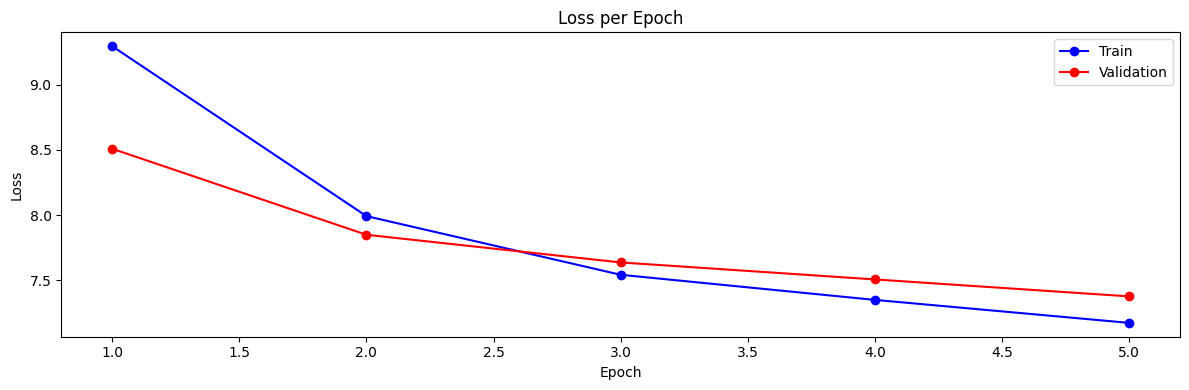

Final train loss: 7.1748
Final validation loss: 7.3780


In [ ]:
# TODO: Create comprehensive training visualization
# TODO: Plot training and validation losses
# TODO: Display final training statistics

### 📊 Evaluation Criteria

Your assignment will be evaluated based on:

1. **Architecture Implementation (50%)**
   - Correct Positional Encoding implementation
   - Proper Transformer Encoder with multi-head attention
   - Correct Transformer Decoder with causal masking
   - Appropriate text generation function
   - Proper handling of padding and special tokens

2. **Training Implementation (30%)**
   - Correct dataset preparation and batching
   - Proper loss calculation with label smoothing
   - Effective training loop with gradient clipping
   - Learning rate scheduling implementation
   - Model convergence and validation

3. **Code Quality and Analysis (20%)**
   - Clean, well-documented code with proper structure
   - Correct ROUGE evaluation
